# 06 — Model Comparison

Loads the three trained models and compares them on the same test set.

Comparison dimensions:
1. Overall metrics (RMSE, MAE, R²)
2. RMSE by prediction horizon
3. RMSE by distance to beach (proxy for how well each model handles extreme stations)
4. Prediction time (relevant for deployment)
5. Final model selection and justification

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import time

from src.utils.config import PATHS, FEATURES, TARGET, SPLIT_DATE, DATASET_FILE
from src.models.evaluate import regression_metrics
from sklearn.metrics import mean_squared_error

print('Libraries loaded OK')

Libraries loaded OK


---
## 1. Load data and models

In [2]:
df = pd.read_parquet(DATASET_FILE)
df['datetime_hour'] = pd.to_datetime(df['datetime_hour'])

test  = df[df['datetime_hour'] >= SPLIT_DATE].copy()
X_test, y_test = test[FEATURES], test[TARGET]

avg_capacity = float(df['capacity'].drop_duplicates().mean())
print(f'Test rows: {len(test):,}')

Test rows: 3,665,100


In [3]:
models = {
    'Linear Regression': joblib.load(PATHS['models'] / 'linear_regression.joblib'),
    'Random Forest':     joblib.load(PATHS['models'] / 'random_forest.joblib'),
    'LightGBM':          joblib.load(PATHS['models'] / 'lightgbm.joblib'),
}
print('Models loaded.')

Models loaded.


---
## 2. Overall metrics

In [4]:
results = {}
preds   = {}

for name, model in models.items():
    t0 = time.perf_counter()
    y_pred = model.predict(X_test)
    elapsed = time.perf_counter() - t0

    preds[name] = y_pred
    m = regression_metrics(y_test, y_pred, label=name, avg_capacity=avg_capacity)
    m['predict_time_s'] = round(elapsed, 3)
    results[name] = m
    print()

df_results = pd.DataFrame(results).T
print('\n--- Summary ---')
print(df_results.round(4).to_string())

  Linear Regression
    RMSE : 0.1964
    MAE  : 0.1529
    R²   : 0.5032
    RMSE in bikes : ±6.4

  Random Forest
    RMSE : 0.1697
    MAE  : 0.1306
    R²   : 0.6291
    RMSE in bikes : ±5.5

  LightGBM
    RMSE : 0.1632
    MAE  : 0.1235
    R²   : 0.6571
    RMSE in bikes : ±5.3


--- Summary ---
                     rmse     mae      r2  predict_time_s
Linear Regression  0.1964  0.1529  0.5032           1.417
Random Forest      0.1697  0.1306  0.6291          36.669
LightGBM           0.1632  0.1235  0.6571          52.840


---
## 3. RMSE by prediction horizon

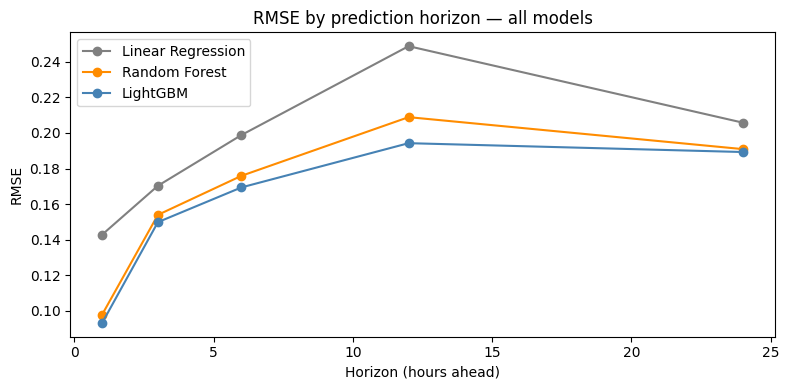

In [5]:
horizons = sorted(test['horizon_hours'].unique())
horizon_results = {name: [] for name in models}

for h in horizons:
    mask = test['horizon_hours'] == h
    for name, y_pred in preds.items():
        rmse = float(np.sqrt(mean_squared_error(y_test[mask], y_pred[mask])))
        horizon_results[name].append(rmse)

fig, ax = plt.subplots(figsize=(8, 4))
colors = {'Linear Regression': 'gray', 'Random Forest': 'darkorange', 'LightGBM': 'steelblue'}
for name, rmses in horizon_results.items():
    ax.plot(horizons, rmses, marker='o', label=name, color=colors[name])

ax.set_xlabel('Horizon (hours ahead)')
ax.set_ylabel('RMSE')
ax.set_title('RMSE by prediction horizon — all models')
ax.legend()
plt.tight_layout()
plt.savefig(PATHS['figures'] / '06_rmse_by_horizon_all.png', dpi=150)
plt.show()

---
## 4. Error by distance to beach

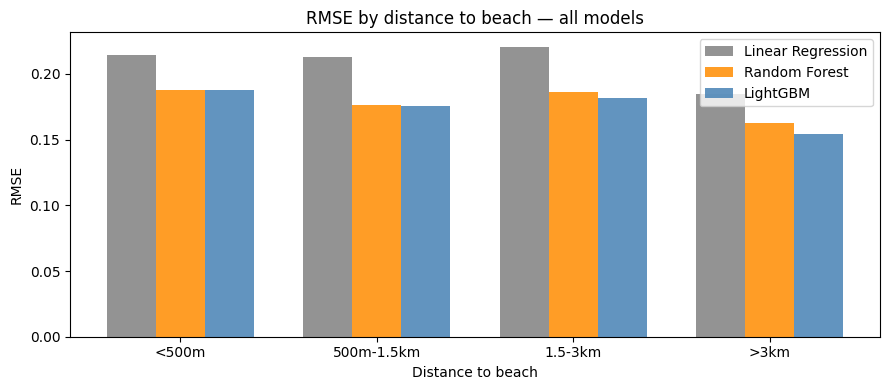

In [6]:
test['dist_group'] = pd.cut(
    test['dist_beach'],
    bins=[0, 0.5, 1.5, 3, 100],
    labels=['<500m', '500m-1.5km', '1.5-3km', '>3km']
)

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(4)
width = 0.25
groups = ['<500m', '500m-1.5km', '1.5-3km', '>3km']

for i, (name, y_pred) in enumerate(preds.items()):
    test_copy = test.copy()
    test_copy['sq_err'] = (y_test.values - y_pred) ** 2
    rmses = [
        float(np.sqrt(test_copy[test_copy['dist_group'] == g]['sq_err'].mean()))
        for g in groups
    ]
    ax.bar(x + i * width, rmses, width, label=name, color=list(colors.values())[i], alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels(groups)
ax.set_xlabel('Distance to beach')
ax.set_ylabel('RMSE')
ax.set_title('RMSE by distance to beach — all models')
ax.legend()
plt.tight_layout()
plt.savefig(PATHS['figures'] / '06_rmse_by_dist_all.png', dpi=150)
plt.show()

---
## 5. Summary table

In [7]:
summary = df_results[['rmse', 'mae', 'r2', 'predict_time_s']].copy()
summary.columns = ['RMSE', 'MAE', 'R²', 'Predict time (s)']

# Highlight best value per metric
print(summary.round(4).to_string())

                     RMSE     MAE      R²  Predict time (s)
Linear Regression  0.1964  0.1529  0.5032             1.417
Random Forest      0.1697  0.1306  0.6291            36.669
LightGBM           0.1632  0.1235  0.6571            52.840


---
## 6. Final model selection

Document here which model was selected and why, based on the numbers above.
Consider: test RMSE, behaviour at short vs long horizons, performance on
beach stations, and prediction latency for deployment.

In [8]:
SELECTED_MODEL = 'LightGBM'  # update if results say otherwise

final_model = models[SELECTED_MODEL]
final_path  = PATHS['models'] / 'final_model.joblib'
joblib.dump(final_model, final_path)
print(f'Final model ({SELECTED_MODEL}) saved to {final_path}')

Final model (LightGBM) saved to C:\Users\user\Downloads\Data Science ML Bicing bcn\Data Science ML Bicing\bicing-occupancy-prediction\models\final_model.joblib
